<a href="https://colab.research.google.com/github/LilianDenzler/Lab_6_workshop/blob/main/workshop.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CBB_5801_2026 - lab 6

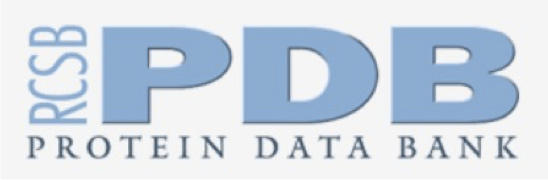

## 1. Data Retrieval from the PDB
The Protein Data Bank contains more than 250,000 protein structures! It is a great resource for protein structure exploration. You can access it like this easily:

* **Website:** [https://www.rcsb.org](https://www.rcsb.org)
* **Search:** Use a **PDB ID** (a unique 4-character code like `1A82`) or keywords (e.g., "Insulin").
* **Download:** * **PDB Format:** The 3D coordinate file.
    * **FASTA:** The amino acid sequence file.


In [1]:
from google.colab import drive
drive.mount('/content/google_drive')

Drive already mounted at /content/google_drive; to attempt to forcibly remount, call drive.mount("/content/google_drive", force_remount=True).


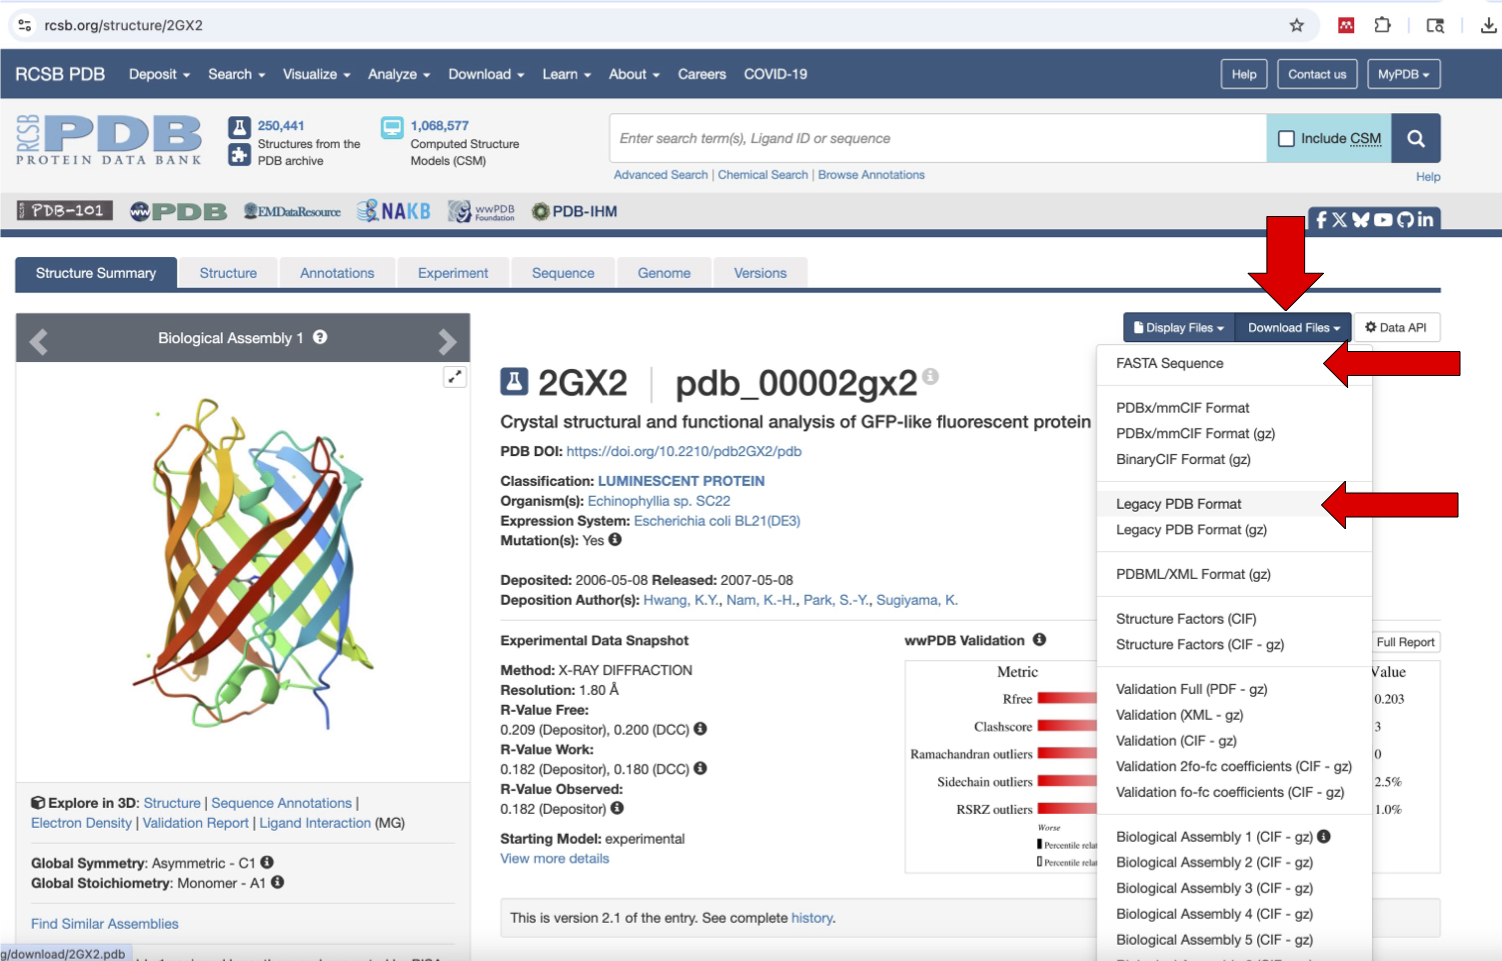

A PDB file is a plain-text document. While it looks like a wall of numbers, it follows a strict hierarchy. Open your downloaded `.pdb` file in a text editor to see these sections:

| Section | Description |
| :--- | :--- |
| **HEADER** | Molecule name, deposition date, and classification. |
| **REMARK 2** | Contains the **Resolution**. A value of $< 2.0$ Å is considered high quality. |
| **SEQRES** | The primary sequence of amino acids (the "alphabet" of the protein). |
| **ATOM** | The 3D coordinates (X, Y, Z) for every atom in the protein backbone and side chains. |
| **HETATM** | "Hetero-atoms"—these are non-protein molecules like water, ions, or bound drugs (ligands). |

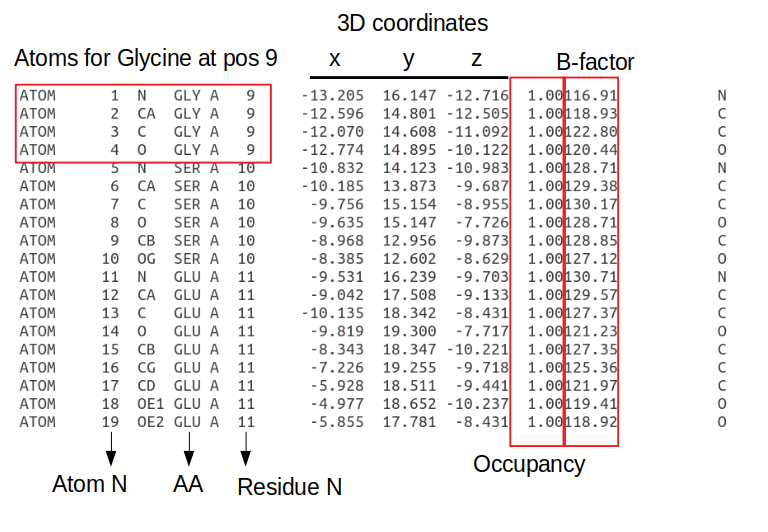


FASTA files are simple text files that save the amino acid residue information per chain. Such as:

```
>2GX2_1|Chain A|fluorescent protein Dronpa|Echinophyllia sp. SC22 (301887)
MRGSHHHHHHGSLVPRGSMVSVIKPDMKIKLRMEGAVNGHPFAIEGVGLGKPFEGKQSMDLKVKEGGPLPFAYDILTTVFSYGNRVFAKYPENIVDYFKQSFPEGYSWERSMNYEDGGICNATNDITLDGDCYIYEIRFDGVNFPANGPVMQKRTVKWEPSTEKLYVRDGVLKGDVNMALSLEGGGHYRCDFKTTYKAKKVVQLPDYHFVDHHIEIKSHDKDYSNVNLHEHAEAHSELPRQAK
>2GX2_2|Chainb B|fluorescent protein Dronpa|Echinophyllia sp. SC22 (301887)
MRGSHHHHHHGSLVPRGSMVSVIKPDMKIKLRMEGAVNGHPFAIEGVGLGKPFEGKQSMDLKVKEGGPLPFAYDILTTVFSYGNRVFAKYPENIVDYFKQSFPEGYSWERSMNYEDGGICNATNDITLDGDCYIYEIRFDGVNFPANGPVMQKRTVKWEPSTEKLYVRDGVLKGDVNMALSLEGGGHYRCDFKTTYKAKKVVQLPDYHFVDHHIEIKSHDKDYSNVNLHEHAEAHSELPRQAK

```

**Task:**

Choose a protein from the PDB and download the PDB file.

## Loading Datafiles

In [2]:
# CELL — Mount Google Drive
from google.colab import drive
drive.mount('/content/google_drive')

Drive already mounted at /content/google_drive; to attempt to forcibly remount, call drive.mount("/content/google_drive", force_remount=True).


In [3]:
# CELL — Set up paths and load all PDB files across all subfolders
import os
import glob
base_path = '/content/google_drive/MyDrive/workshop_datafiles'

In [4]:
#Download datafiles from github

# 1. Mount Google Drive
drive.mount('/content/google_drive')

# 2. Define your target path and the repo
TARGET_DIR = base_path
REPO_URL = "https://github.com/LilianDenzler/Lab_6_workshop.git"
SUB_FOLDER = "workshop_datafiles"

# 3. Clean up any existing temp folders to avoid conflicts
!rm -rf temp_repo

# 4. Perform a Sparse Checkout (downloading ONLY the specific folder)
!git init temp_repo
%cd temp_repo
!git remote add -f origin {REPO_URL}
!git config core.sparseCheckout true

# Specify the sub-folder in the sparse-checkout config
with open(".git/info/sparse-checkout", "w") as f:
    f.write(SUB_FOLDER + "/")

# Pull from the 'main' branch
!git pull origin main

# 5. Move the files to your Drive path
# If the target directory already exists, we copy the contents inside
!mkdir -p "{TARGET_DIR}"
!cp -r {SUB_FOLDER}/* "{TARGET_DIR}/"

# 6. Clean up the temporary local repo
%cd /content
!rm -rf temp_repo

print(f"\n✅ Success! Your files are now at: {TARGET_DIR}")
!ls "{TARGET_DIR}"

Drive already mounted at /content/google_drive; to attempt to forcibly remount, call drive.mount("/content/google_drive", force_remount=True).
hint: Using 'master' as the name for the initial branch. This default branch name
hint: is subject to change. To configure the initial branch name to use in all
hint: of your new repositories, which will suppress this warning, call:
hint: 
hint: 	git config --global init.defaultBranch <name>
hint: 
hint: Names commonly chosen instead of 'master' are 'main', 'trunk' and
hint: 'development'. The just-created branch can be renamed via this command:
hint: 
hint: 	git branch -m <name>
Initialized empty Git repository in /content/temp_repo/.git/
/content/temp_repo
Updating origin
remote: Enumerating objects: 79, done.
remote: Counting objects: 100% (79/79), done.
remote: Compressing objects: 100% (61/61), done.
remote: Total 79 (delta 41), reused 36 (delta 18), pack-reused 0 (from 0)
Unpacking objects: 100% (79/79), 4.03 MiB | 785.00 KiB/s, done.
From

In [5]:
# Automatically finds all PDB files in all subfolders
pdb_files = glob.glob(os.path.join(base_path, '**/*.pdb'), recursive=True)

# Organize into a dictionary by folder name
pdb_dict = {}
for pdb_path in pdb_files:
    folder_name = os.path.basename(os.path.dirname(pdb_path))
    if folder_name not in pdb_dict:
        pdb_dict[folder_name] = []
    pdb_dict[folder_name].append(pdb_path)

# Print summary so students can confirm what loaded
for folder, files in pdb_dict.items():
    print(f"\n {folder}:")
    for f in files:
        print(f"   - {os.path.basename(f)}")


 workshop_datafiles:
   - 8YIV.pdb
   - model_0.pdb
   - model_1.pdb
   - model_2.pdb
   - model_3.pdb
   - model_4.pdb
   - aligned_model.pdb


**Task:**

Upload your chosen PDB file to the workshop_datafiles folder.

## Visualising Protein Strutuctues in Colab Notebook

Most commonly, pymol is used for protein visualisation (https://www.pymol.org/)
However, in interactive notebooks py3Dmol is most convenient!

In [6]:
!pip install py3Dmol
import py3Dmol
!pip install -U prody
import prody

view = py3Dmol.view()
view.addModel(open(os.path.join(base_path,'8YIV.pdb'), 'r').read(),'pdb')
view.setBackgroundColor('white')
view.setStyle({'chain':'A'}, {'cartoon': {'color':'purple'}})
view.setStyle({'chain':'B'}, {'cartoon': {'color':'blue'}})
view.setStyle({'chain':'D'}, {'cartoon': {'color':'red'}})
view.setStyle({'chain':'E'}, {'cartoon': {'color':'green'}})
view.setStyle({'chain':'C'}, {'cartoon': {'color':'orange'}})
view.zoomTo()
view.show()

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

**Task:**

Visualise your chosen Protein, colouring each chain differently. Play around with different visualisation methods. Use this helpful guide on py3Dmol https://william-dawson.github.io/using-py3dmol.html

## Structure Superposition
Superposition means finding a rigid-body rotation and translation that best overlays two structures.
Here we superpose the original structure of the TCRpMHC complex and the alphafold3 generated model_0.pdb. We use the TCR chains for fitting.

Two ways to define which residues correspond:
1) index-based (structural) pairing: residue 1 in one structure is paired with residue 1 in the other, up to the shorter length.
   This is quick but can fail if the constructs differ by insertions/deletions or missing termini.
2) sequence-aligned pairing: first align the amino-acid sequences, then only fit residues aligned without gaps.
   This is the safer default when sequences/constructs differ.

We will be using BioPython’s Superimposer.
RMSD is reported for the atoms used in the fit (Cα or backbone).

If you are superposing two proteins with the same sequence, the sequence alignment can be skipped. The alignment is shown here for completion.

In [7]:
import os
from pathlib import Path
import numpy as np
from Bio.PDB import PDBParser, Superimposer, PDBIO
from Bio.SeqUtils import seq1
from Bio.Align import PairwiseAligner

def load_structure(pdb_path):
    parser = PDBParser(QUIET=True)
    return parser.get_structure(Path(pdb_path).stem, str(pdb_path))

def standard_residues(chain):
    """Filters for standard protein residues (no HETATMs)."""
    return [r for r in chain.get_residues() if r.id[0] == " "]

def one_letter_seq(residues):
    out = []
    for r in residues:
        try:
            out.append(seq1(r.get_resname()))
        except Exception:
            out.append("X")
    return "".join(out)

def get_residue_pairs(ref_chain, mob_chain, exact_match=False):
    """Pairs residues between two chains using alignment or direct indexing."""
    ref_res = standard_residues(ref_chain)
    mob_res = standard_residues(mob_chain)

    if exact_match:
        # Assumes same length and same residues in same order
        n = min(len(ref_res), len(mob_res))
        return list(zip(ref_res[:n], mob_res[:n]))

    # Global Alignment logic for different lengths/sequences
    aligner = PairwiseAligner()
    aligner.mode = "global"
    ref_seq = one_letter_seq(ref_res)
    mob_seq = one_letter_seq(mob_res)

    try:
        # Take the first best alignment
        aln = aligner.align(mob_seq, ref_seq)[0]
        mob_blocks, ref_blocks = aln.aligned
        pairs = []
        for (ms, me), (rs, re) in zip(mob_blocks, ref_blocks):
            for k in range(me - ms):
                pairs.append((ref_res[rs + k], mob_res[ms + k]))
        return pairs
    except Exception as e:
        print(f"Warning: Alignment failed for {ref_chain.id}/{mob_chain.id}: {e}")
        return []

def fit_multi_chain_mapped(ref_pdb, mob_pdb, chain_map, atom_names=("CA",), exact_match=False, out_pdb=None):
    """
    Fits mob_pdb onto ref_pdb based on a chain map {ref_id: mob_id}.
    Example chain_map: {"D": "A", "E": "B"}
    """
    ref_struct = load_structure(ref_pdb)
    mob_struct = load_structure(mob_pdb)

    ref_atoms_all = []
    mob_atoms_all = []

    for ref_cid, mob_cid in chain_map.items():
        if ref_cid not in ref_struct[0]:
            print(f"Ref chain {ref_cid} not found.")
            continue
        if mob_cid not in mob_struct[0]:
            print(f"Mob chain {mob_cid} not found.")
            continue

        ref_chain = ref_struct[0][ref_cid]
        mob_chain = mob_struct[0][mob_cid]

        # Get pairs for this specific chain mapping
        res_pairs = get_residue_pairs(ref_chain, mob_chain, exact_match=exact_match)

        for r_ref, r_mob in res_pairs:
            if all(a in r_ref and a in r_mob for a in atom_names):
                for a in atom_names:
                    ref_atoms_all.append(r_ref[a])
                    mob_atoms_all.append(r_mob[a])

    if not ref_atoms_all:
        print("No atom pairs found for superposition.")
        return None, 0

    # 1. Initialize Superimposer
    sup = Superimposer()
    sup.set_atoms(ref_atoms_all, mob_atoms_all)

    # 2. Apply to the entire mobile structure (moves all chains as a rigid body)
    sup.apply(mob_struct.get_atoms())

    # 3. Save result
    if out_pdb:
        io = PDBIO()
        io.set_structure(mob_struct)
        io.save(str(out_pdb))

    return sup.rms, len(ref_atoms_all)

In [8]:
# Define the chains to use for alignment (e.g., TCR Alpha and Beta)
MAPPING = {"D": "A", "E": "B"}
REF_FILE=os.path.join(base_path,'8YIV.pdb')
MOB_FILE=os.path.join(base_path,'model_0.pdb')
# 1. Align on Alpha Carbons, exact sequence match
rms, n_atoms = fit_multi_chain_mapped(
        REF_FILE, MOB_FILE, MAPPING,
        atom_names=("CA",),
        exact_match=True,
        out_pdb=os.path.join(base_path,"aligned_model.pdb"))

print(f"Multi-chain RMSD : {rms:.3f} Å")

Multi-chain RMSD : 2.566 Å


**Task:**

Superpose your structure onto itself as sanity check and report the RMSD. Also calculate the backbone RMSD for the TCR example shown above.

## Running Alphafold

The Alphafold3 webserver is freely available for structure generation at https://alphafoldserver.com/. However there is a limit to 30 runs per day.

You need to set the seed to produce reproducible results.
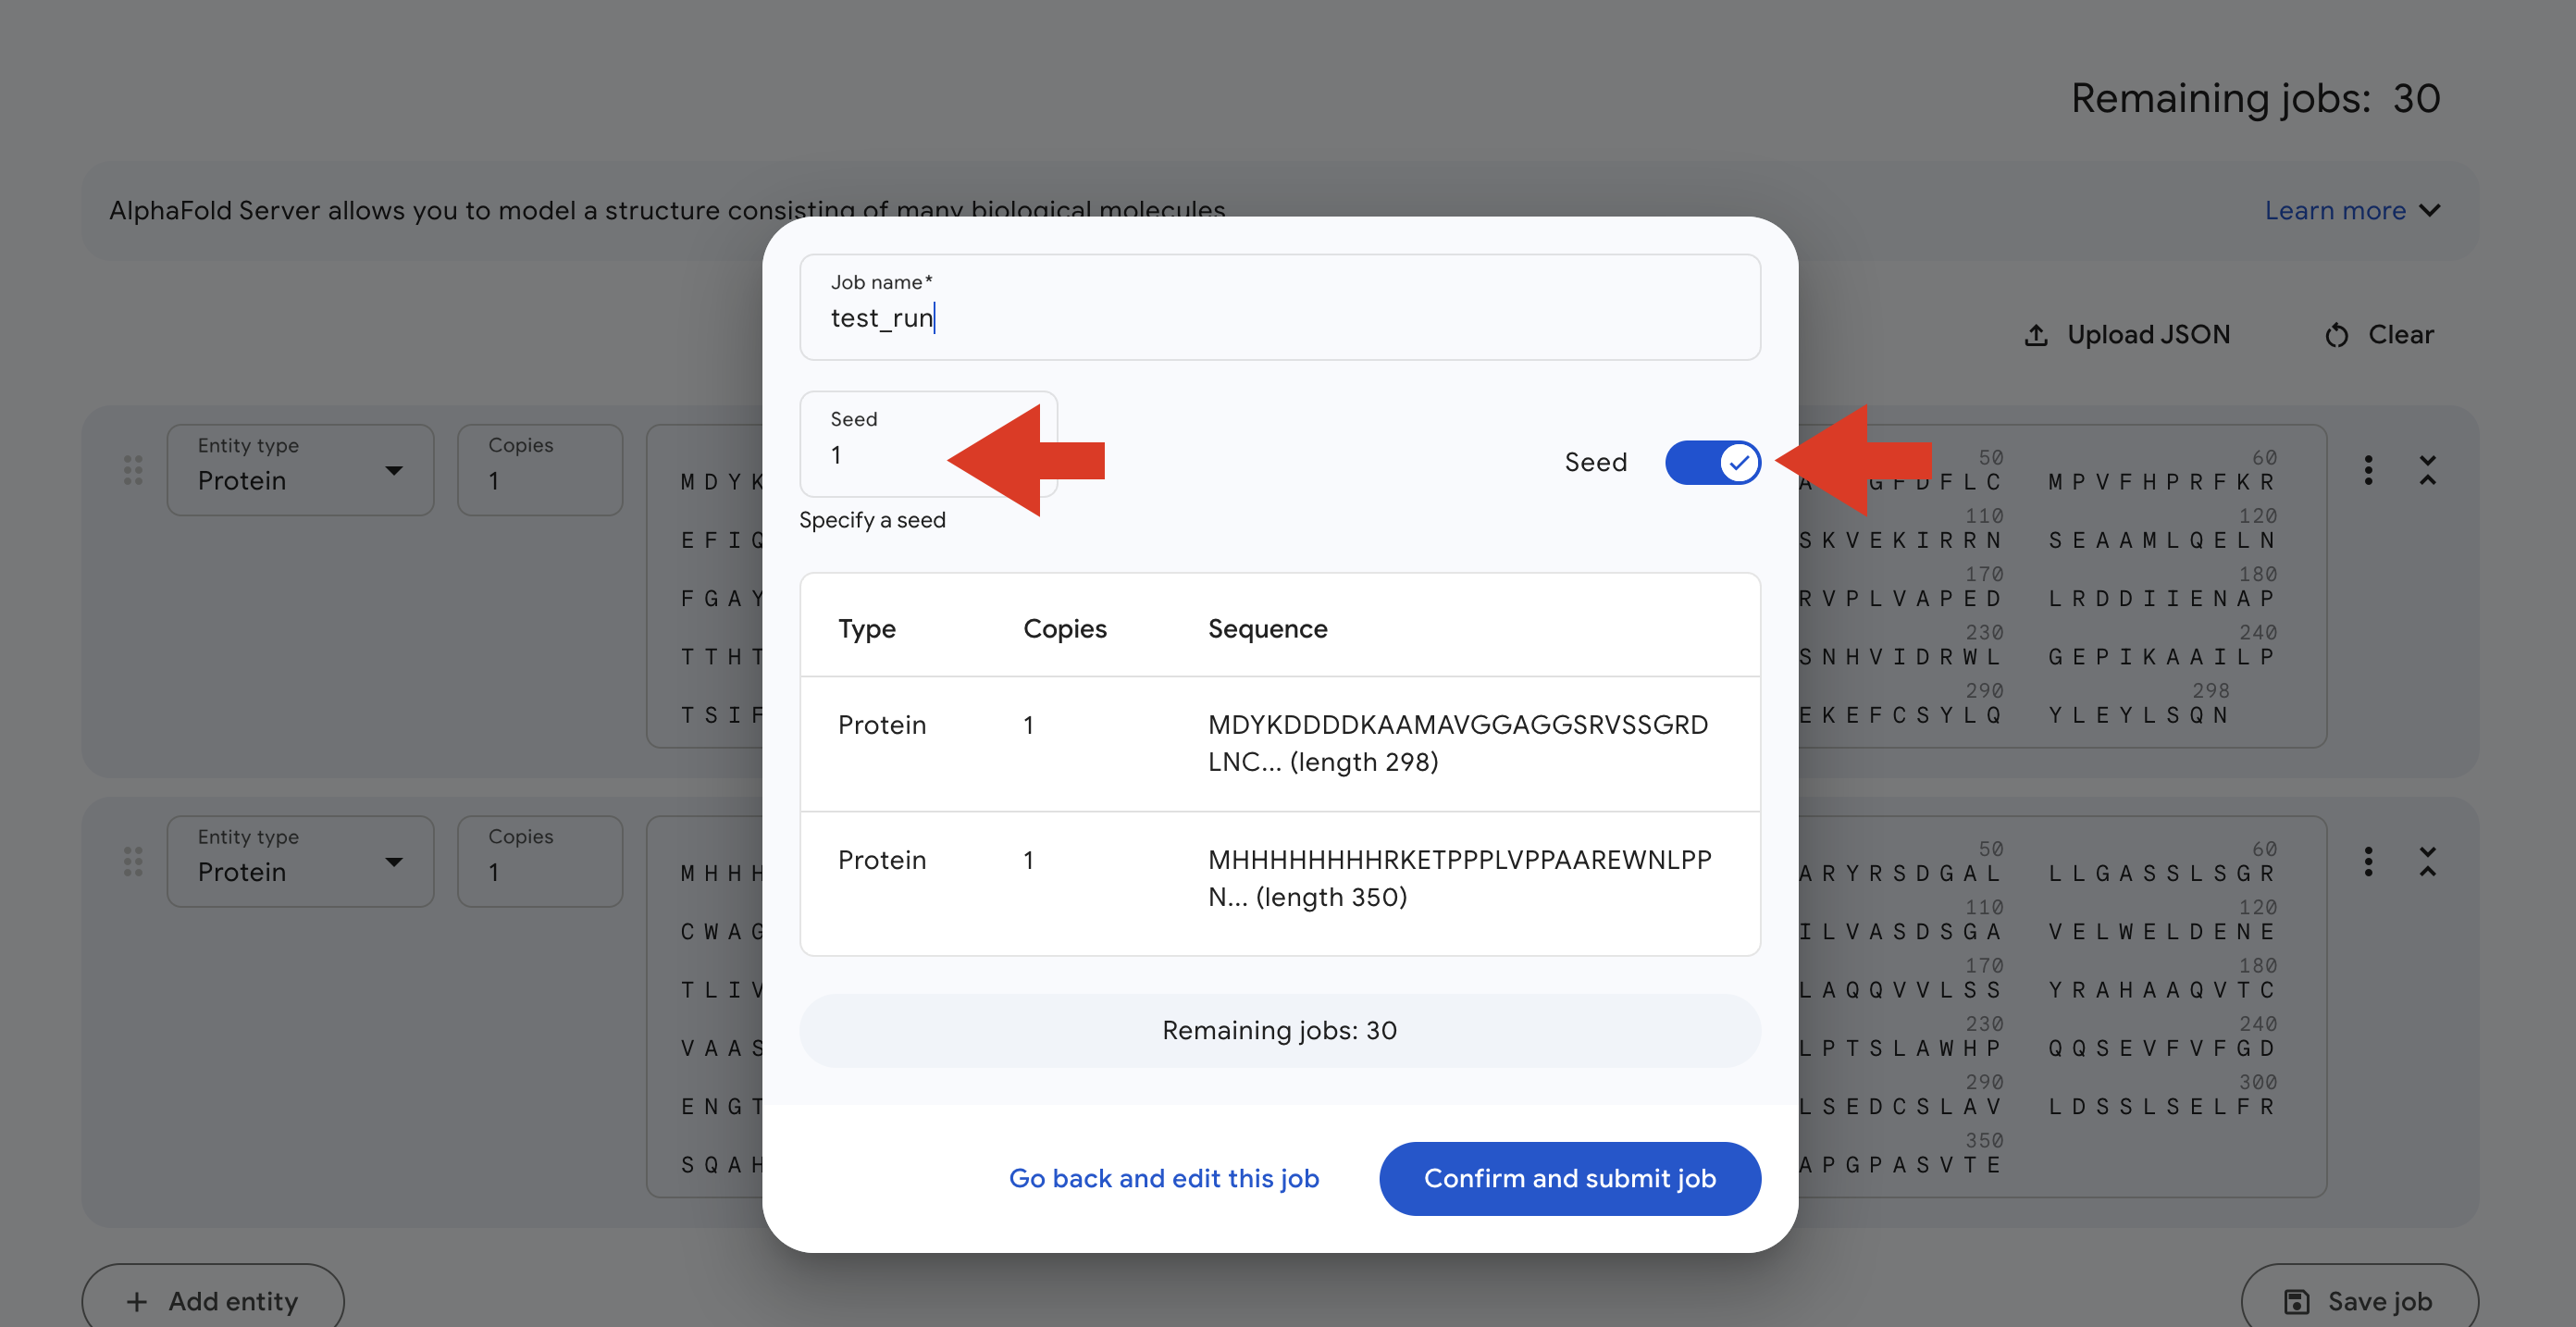

**Task:**

Run Alphafold3 on your chosen protein and analyse the output. Download the results.

## Energy Calculations

In [9]:
#Install Pyrosetta
!pip install pyrosettacolabsetup
import pyrosettacolabsetup; pyrosettacolabsetup.install_pyrosetta()
from pyrosetta import *
!pip install py3Dmol

import numpy as np
import pandas as pd
import os
pyrosetta.init()

┌───────────────────────────────────────────────────────────────────────────────┐
│                                  PyRosetta-4                                  │
│               Created in JHU by Sergey Lyskov and PyRosetta Team              │
│               (C) Copyright Rosetta Commons Member Institutions               │
│                                                                               │
│ NOTE: USE OF PyRosetta FOR COMMERCIAL PURPOSES REQUIRES PURCHASE OF A LICENSE │
│          See LICENSE.PyRosetta.md or email license@uw.edu for details         │
└───────────────────────────────────────────────────────────────────────────────┘
PyRosetta-4 2026 [Rosetta PyRosetta4.Release.python312.ubuntu 2026.03+releasequarterly.5e498f1409c68ade56c8ce5842bf79e1b02e8db4 2026-01-13T13:24:11] retrieved from: http://www.pyrosetta.org
core.init: Checking for fconfig files in pwd and ./rosetta/flags
core.init: Rosetta version: PyRosetta4.Release.python312.ubuntu r1 2026.03+releasequarter

In [10]:
def calculate_energy_raw(pdb_path, label=""):
    """
    Calculate Rosetta energy WITHOUT any optimization
    """
    try:
        pose = pose_from_pdb(pdb_path)
        sfxn = get_fa_scorefxn()
        total_energy = sfxn(pose)

        print(f"✓ {label}: {total_energy:.2f} REU")
        return {
            'label': label,
            'total_energy': total_energy,
            'pose': pose,
            'type': 'raw'
        }
    except Exception as e:
        print(f"✗ Error: {e}")
        return None

In [11]:
out=calculate_energy_raw(os.path.join(base_path,"8YIV.pdb"))
print(out)

core.chemical.GlobalResidueTypeSet: Finished initializing fa_standard residue type set.  Created 985 residue types
core.chemical.GlobalResidueTypeSet: Total time to initialize 1.32482 seconds.
core.import_pose.import_pose: File '/content/google_drive/MyDrive/workshop_datafiles/8YIV.pdb' automatically determined to be of type PDB from contents.
core.chemical.GlobalResidueTypeSet: Loading (but possibly not actually using) 'GOL' from the PDB components dictionary for residue type 'pdb_GOL'
core.chemical.GlobalResidueTypeSet: Loading (but possibly not actually using) 'EDO' from the PDB components dictionary for residue type 'pdb_EDO'
core.conformation.Conformation: [ WARNING ] missing heavyatom:  CG  on residue GLN 226
core.conformation.Conformation: [ WARNING ] missing heavyatom:  CD  on residue GLN 226
core.conformation.Conformation: [ WARNING ] missing heavyatom:  OE1 on residue GLN 226
core.conformation.Conformation: [ WARNING ] missing heavyatom:  NE2 on residue GLN 226
core.conformat

In [12]:
def energies_by_residues(pdb_path):
  energy_data = []
  pose = pose_from_pdb(pdb_path)
  sfxn = get_fa_scorefxn()
  total_energy = sfxn(pose)
  # Iterate through every residue in the pose
  for i in range(1, pose.total_residue() + 1):
      res_energy = pose.energies().residue_total_energy(i)
      res_name = pose.residue(i).name()
      chain = pose.pdb_info().chain(i)
      pdb_num = pose.pdb_info().number(i)

      energy_data.append({
          "Residue_Index": i,
          "PDB_Number": pdb_num,
          "Chain": chain,
          "Type": res_name,
          "Energy_REU": res_energy
      })

  return pd.DataFrame(energy_data)

In [13]:
df_energies=energies_by_residues(os.path.join(base_path,"model_0.pdb"))
# Show the 10 residues with the highest (worst) energy - potential clashes
print("Top 10 High-Energy Residues (Potential Clashes):")
display(df_energies.sort_values("Energy_REU", ascending=False).head(10))

core.import_pose.import_pose: File '/content/google_drive/MyDrive/workshop_datafiles/model_0.pdb' automatically determined to be of type PDB from contents.
core.io.pdb.HeaderInformation: [ WARNING ] Deposition day not in range [1, 31]: 0
core.io.pdb.HeaderInformation: [ WARNING ] Unrecognized month in HEADER deposition date
core.conformation.Conformation: Found disulfide between residues 24 92
core.conformation.Conformation: Found disulfide between residues 136 186
core.conformation.Conformation: Found disulfide between residues 161 381
core.conformation.Conformation: Found disulfide between residues 231 299
core.conformation.Conformation: Found disulfide between residues 355 420
core.conformation.Conformation: Found disulfide between residues 556 619
core.conformation.Conformation: Found disulfide between residues 658 714
core.conformation.Conformation: Found disulfide between residues 766 821
core.scoring.ScoreFunctionFactory: SCOREFUNCTION: ref2015
Top 10 High-Energy Residues (Poten

,Residue_Index,PDB_Number,Chain,Type,Energy_REU
30,31,31,A,TRP,44.686895
624,625,171,C,ARG,39.341937
526,527,73,C,GLN,15.751541
307,308,101,B,LEU,15.296439
35,36,36,A,PHE,15.242305
306,307,100,B,PRO,14.982688
609,610,156,C,GLN,14.580329
261,262,55,B,VAL,14.548895
237,238,31,B,GLU,13.156910
167,168,168,A,MET,12.477702


**Task:**

Calculate the Rosetta Energy of your chosen protein. Identify the 10 highest energy residues.

Optional: visualise your protein with the high-energy residues highlighted.

## Calculate Energies of Alphafold3 models

In [14]:
# Calculate energies for AF3 models
print("\n" + "="*60)
print("CALCULATING ENERGIES FOR AF3 MODELS")
print("="*60)

af3_raw_results = []
af3_min_results = []
model_pdbs=[os.path.join(base_path,model_file) for model_file in os.listdir(base_path) if "model" in model_file]
for i, model_pdb in enumerate(model_pdbs):
    print(f"\n--- Model {i} ---")
    raw = calculate_energy_raw(model_pdb, f"AF3 Model {i} (Raw)")
    if raw:
        af3_raw_results.append(raw)

print("\n✓ Energy calculations complete!")


CALCULATING ENERGIES FOR AF3 MODELS

--- Model 0 ---
core.import_pose.import_pose: File '/content/google_drive/MyDrive/workshop_datafiles/model_0.pdb' automatically determined to be of type PDB from contents.
core.io.pdb.HeaderInformation: [ WARNING ] Deposition day not in range [1, 31]: 0
core.io.pdb.HeaderInformation: [ WARNING ] Unrecognized month in HEADER deposition date
core.conformation.Conformation: Found disulfide between residues 24 92
core.conformation.Conformation: Found disulfide between residues 136 186
core.conformation.Conformation: Found disulfide between residues 161 381
core.conformation.Conformation: Found disulfide between residues 231 299
core.conformation.Conformation: Found disulfide between residues 355 420
core.conformation.Conformation: Found disulfide between residues 556 619
core.conformation.Conformation: Found disulfide between residues 658 714
core.conformation.Conformation: Found disulfide between residues 766 821
core.scoring.ScoreFunctionFactory: SCO

In [15]:
# Compile all energy data
energy_summary = []

# AF3 model data
for result in af3_raw_results:
    model_num = result['label'].split()[2]
    energy_summary.append({
        'Structure': f'AF3 Model {model_num}',
        'Type': 'Raw',
        'Energy_REU': result['total_energy']
    })

df_energy = pd.DataFrame(energy_summary)

print("\n" + "="*60)
print("ENERGY SUMMARY TABLE")
print("="*60)
print(df_energy.to_string(index=False))


ENERGY SUMMARY TABLE
  Structure Type   Energy_REU
AF3 Model 0  Raw -1041.508448
AF3 Model 1  Raw -1109.713871
AF3 Model 2  Raw -1112.815773
AF3 Model 3  Raw  -736.020717
AF3 Model 4  Raw -1058.254131
AF3 Model 5  Raw -1041.581472


**Plot Rosetta Energies**

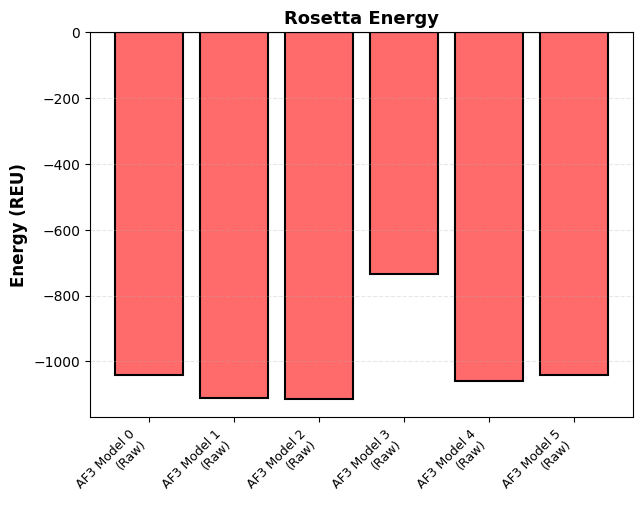

In [16]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 5))

structures = df_energy['Structure'].unique()

# Organize data for plotting
energy_values = []
labels_final = []
for struct in sorted(structures):
    struct_data = df_energy[df_energy['Structure'] == struct]
    raw_val = struct_data[struct_data['Type'] == 'Raw']['Energy_REU'].values

    if len(raw_val) > 0:
        energy_values.append(raw_val[0])
        labels_final.append(f"{struct}\n(Raw)")

x = np.arange(len(energy_values))
colors = ['#FF6B6B' if 'Raw' in label else '#95E1D3' for label in labels_final]

ax.bar(x, energy_values, color=colors, edgecolor='black', linewidth=1.5)
ax.set_ylabel('Energy (REU)', fontsize=12, fontweight='bold')
ax.set_title('Rosetta Energy', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(labels_final, rotation=45, ha='right', fontsize=9)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.8)

In [17]:
# ---------------------------------------------------------------------------
# Helpers
# ---------------------------------------------------------------------------
from Bio.PDB import NeighborSearch
import matplotlib.patches as mpatches
def _merge_ordered(lists):
    return list(dict.fromkeys(item for lst in lists for item in lst))


def _format_label(res_id):
    if res_id.startswith("TCR_alpha_"):
        return "α" + res_id[len("TCR_alpha_"):]
    if res_id.startswith("TCR_beta_"):
        return "β" + res_id[len("TCR_beta_"):]
    return res_id.replace("peptide_", "")


# ---------------------------------------------------------------------------
# 1. Contact calculation
# ---------------------------------------------------------------------------

def calculate_contacts(pdb_path, chain_mapping, distance_cutoff=5.0):
    """
    Find minimum-distance ATOM-only contacts between (TCR_alpha + TCR_beta)
    and the peptide chain.

    Returns
    -------
    contacts    : set of (tcr_res_id, pep_res_id) e.g. ("TCR_alpha_4", "peptide_3")
    tcr_res_ids : list[str] – ordered TCR residue IDs (alpha first, then beta)
    pep_res_ids : list[str] – ordered peptide residue IDs
    """
    model = PDBParser(QUIET=True).get_structure("p", pdb_path)[0]

    pep_atoms, pep_res_ids = [], []
    for res in model[chain_mapping["peptide"]]:
        if res.id[0] != " ":
            continue
        rid = f"peptide_{res.id[1]}"
        if rid not in pep_res_ids:
            pep_res_ids.append(rid)
        pep_atoms.extend(res.get_atoms())

    tcr_atom_info, tcr_res_ids = [], []
    for role, key in [("TCR_alpha", "TCR_alpha"), ("TCR_beta", "TCR_beta")]:
        for res in model[chain_mapping[key]]:
            if res.id[0] != " ":
                continue
            rid = f"{role}_{res.id[1]}"
            if rid not in tcr_res_ids:
                tcr_res_ids.append(rid)
            for atom in res:
                tcr_atom_info.append((atom, rid))

    ns = NeighborSearch(pep_atoms)
    min_dist = {}
    for atom, tcr_rid in tcr_atom_info:
        for close_atom in ns.search(atom.coord, distance_cutoff):
            pep_res = close_atom.get_parent()
            if pep_res.id[0] != " ":
                continue
            pair = (tcr_rid, f"peptide_{pep_res.id[1]}")
            dist = np.linalg.norm(atom.coord - close_atom.coord)
            if pair not in min_dist or dist < min_dist[pair]:
                min_dist[pair] = dist

    return set(min_dist.keys()), tcr_res_ids, pep_res_ids


# ---------------------------------------------------------------------------
# 2. Plotting
# ---------------------------------------------------------------------------

def plot_tcr_peptide_contacts(
    crystal_contacts,
    model_contacts_list,
    tcr_res_ids,
    pep_res_ids,
    title="TCR–Peptide Contact Map",
    save_path=None,
):
    """
    White  = no AF3 model contact
    Black  = AF3 contact; number inside = how many models share it
    Red    = small box in upper-left corner marks a crystal contact
    """
    n_tcr, n_pep = len(tcr_res_ids), len(pep_res_ids)
    n_models = len(model_contacts_list)

    tcr_idx = {r: i for i, r in enumerate(tcr_res_ids)}
    pep_idx = {r: i for i, r in enumerate(pep_res_ids)}

    # After building count_matrix, before the figure
    all_contacts = crystal_contacts | {p for mc in model_contacts_list for p in mc}
    active_tcr = {tr for tr, pr in all_contacts if tr in tcr_idx and pr in pep_idx}
    tcr_res_ids = [r for r in tcr_res_ids if r in active_tcr]
    tcr_idx     = {r: i for i, r in enumerate(tcr_res_ids)}   # rebuild index
    n_tcr       = len(tcr_res_ids)

    # Count matrix
    count_matrix = np.zeros((n_tcr, n_pep), dtype=int)
    for mc in model_contacts_list:
        for tr, pr in mc:
            if tr in tcr_idx and pr in pep_idx:
                count_matrix[tcr_idx[tr], pep_idx[pr]] += 1

    # Figure
    cell_w, cell_h = 0.55, 0.35
    fig, ax = plt.subplots(figsize=(max(6, n_pep * cell_w + 3),
                                    max(6, n_tcr * cell_h + 3)))

    # Single imshow call for white/black grid
    ax.imshow(
        (count_matrix > 0).astype(float),
        cmap="gray_r", aspect="auto", origin="lower", vmin=0, vmax=1,
        extent=[-0.5, n_pep - 0.5, -0.5, n_tcr - 0.5],
    )

    # Grid lines
    ax.set_xticks(np.arange(-0.5, n_pep, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, n_tcr, 1), minor=True)
    ax.grid(which="minor", color="#cccccc", linewidth=0.4)
    ax.tick_params(which="minor", length=0)

    # Count labels (only non-zero cells)
    for i, j in zip(*np.where(count_matrix > 0)):
        ax.text(j, i, str(count_matrix[i, j]),
                ha="center", va="center",
                color="white", fontsize=7, fontweight="bold")

    # Red crystal markers (only contact cells)
    RED = 0.30
    for tr, pr in crystal_contacts:
        if tr in tcr_idx and pr in pep_idx:
            i, j = tcr_idx[tr], pep_idx[pr]
            ax.add_patch(mpatches.Rectangle(
                (j - 0.5, i - 0.5 + (1 - RED)), RED, RED,
                facecolor="red", linewidth=0, zorder=3,
            ))

    # Axes labels
    ax.set_xticks(range(n_pep))
    ax.set_xticklabels([_format_label(r) for r in pep_res_ids], fontsize=8)
    ax.set_yticks(range(n_tcr))
    ax.set_yticklabels([_format_label(r) for r in tcr_res_ids], fontsize=7)
    ax.set_xlabel("Peptide Residues", fontsize=11, fontweight="bold")
    ax.set_ylabel("TCR Residues  (α → β)", fontsize=11, fontweight="bold")
    ax.set_title(title, fontsize=13, fontweight="bold", pad=10)

    # Alpha/beta divider
    n_alpha = sum(1 for r in tcr_res_ids if r.startswith("TCR_alpha"))
    if 0 < n_alpha < n_tcr:
        ax.axhline(n_alpha - 0.5, color="steelblue",
                   linewidth=1.5, linestyle="--", alpha=0.8)
        ax.text(-0.6, n_alpha - 0.5, "α|β",
                va="center", ha="right", fontsize=8,
                color="steelblue", fontweight="bold")

    # Legend
    ax.legend(handles=[
        mpatches.Patch(facecolor="black", edgecolor="gray",
                       label=f"AF3 contact  (n / {n_models} models)"),
        mpatches.Patch(facecolor="white", edgecolor="gray",
                       label="No contact"),
        mpatches.Patch(facecolor="red",
                       label="Crystal contact"),
    ], loc="upper right", fontsize=8, framealpha=0.9)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"✓ Saved to {save_path}")
    plt.show()


# ---------------------------------------------------------------------------
# 3. Orchestration
# ---------------------------------------------------------------------------

def run_contact_analysis(
    crystal_path,
    model_paths,
    crystal_chain_mapping,
    af3_chain_mapping,
    distance_cutoff=5.0,
    title="TCR–Peptide Contact Map",
    save_path=None,
):
    """
    Full pipeline: contacts for crystal + all AF3 models → plot.

    Example
    -------
    run_contact_analysis(
        crystal_path          = '/content/drive/.../8YIV/8YIV.pdb',
        model_paths           = ['.../model_0.pdb', ..., '.../model_4.pdb'],
        crystal_chain_mapping = {'TCR_alpha':'D','TCR_beta':'E','peptide':'C', ...},
        af3_chain_mapping     = {'TCR_alpha':'A','TCR_beta':'B','peptide':'D', ...},
        distance_cutoff       = 5.0,
        title                 = '8YIV TCR–Peptide Contacts',
    )
    """
    print("Calculating crystal contacts …")
    crystal_contacts, c_tcr, c_pep = calculate_contacts(
        crystal_path, crystal_chain_mapping, distance_cutoff)
    print(f"  {len(crystal_contacts)} pairs")

    model_contacts_list, all_tcr, all_pep = [], [c_tcr], [c_pep]
    for i, path in enumerate(model_paths):
        print(f"Calculating model_{i} contacts …")
        contacts, m_tcr, m_pep = calculate_contacts(
            path, af3_chain_mapping, distance_cutoff)
        model_contacts_list.append(contacts)
        all_tcr.append(m_tcr)
        all_pep.append(m_pep)
        print(f"  {len(contacts)} pairs")

    tcr_res_ids = _merge_ordered(all_tcr)
    pep_res_ids = _merge_ordered(all_pep)

    print(f"\nPlotting ({len(tcr_res_ids)} TCR × {len(pep_res_ids)} peptide residues) …")
    plot_tcr_peptide_contacts(
        crystal_contacts, model_contacts_list,
        tcr_res_ids, pep_res_ids,
        title=title, save_path=save_path,
    )


print("✓ Contact map functions defined")

✓ Contact map functions defined



CONTACT MAP ANALYSIS: CRYSTAL STRUCTURE (8YIV)
Calculating crystal contacts …
  24 pairs
Calculating model_0 contacts …
  19 pairs
Calculating model_1 contacts …
  20 pairs
Calculating model_2 contacts …
  21 pairs
Calculating model_3 contacts …
  22 pairs
Calculating model_4 contacts …
  20 pairs
Calculating model_5 contacts …
  19 pairs

Plotting (454 TCR × 10 peptide residues) …


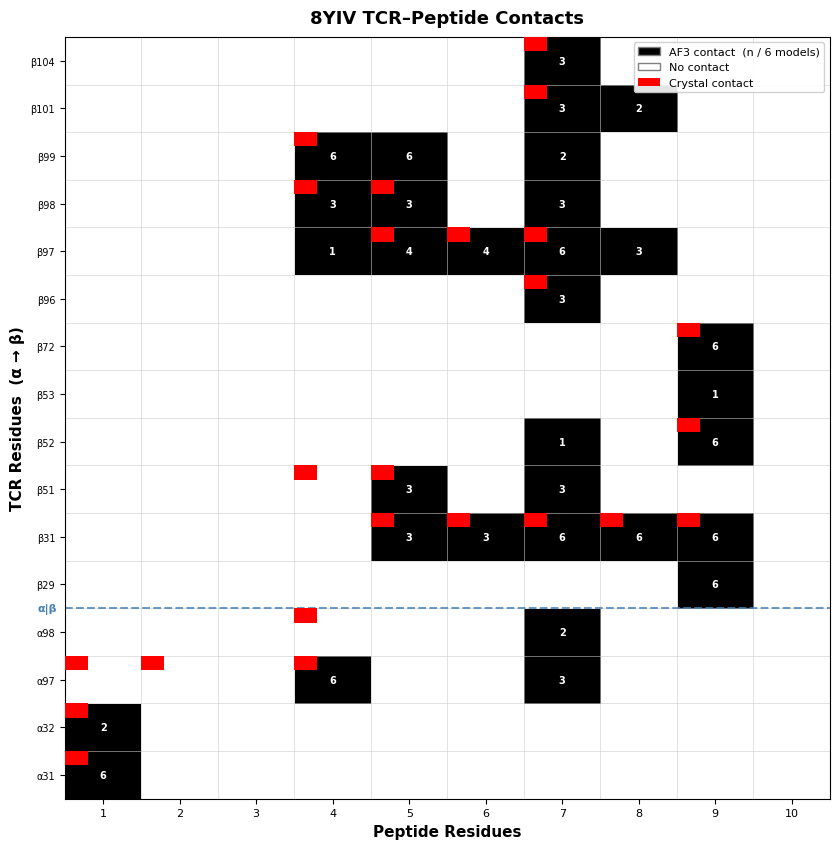

In [18]:
print("\n" + "="*60)
print("CONTACT MAP ANALYSIS: CRYSTAL STRUCTURE (8YIV)")
print("="*60)

CRYSTAL_CHAIN_MAP = {'TCR_alpha': 'D', 'TCR_beta': 'E', 'MHC_heavy': 'A',
                     'peptide': 'C', 'B2M': 'B'}
AF3_CHAIN_MAP     = {'TCR_alpha': 'A', 'TCR_beta': 'B', 'MHC_heavy': 'C',
                     'peptide': 'D', 'B2M': 'E'}

CRYSTAL_PATH = os.path.join(base_path,'8YIV.pdb')
MODEL_PATHS  = [os.path.join(base_path,model_file) for model_file in os.listdir(base_path) if "model" in model_file]

run_contact_analysis(
    crystal_path          = CRYSTAL_PATH,
    model_paths           = MODEL_PATHS,
    crystal_chain_mapping = CRYSTAL_CHAIN_MAP,
    af3_chain_mapping     = AF3_CHAIN_MAP,
    distance_cutoff       = 5.0,
    title                 = '8YIV TCR–Peptide Contacts',
)

In [19]:
import statistics
def get_contact_avg_plddt(pdb_path, contacts, chain_mapping):
    """
    Average pLDDT over all residues involved in contact pairs.

    Parameters
    ----------
    pdb_path      : str  – path to AF3 model PDB
    contacts      : set of (tcr_res_id, pep_res_id) from calculate_contacts
    chain_mapping : dict – e.g. {'TCR_alpha':'A','TCR_beta':'B','peptide':'D',...}

    Returns
    -------
    float – single average pLDDT across all contact residues, or None if no contacts
    """
    # Build reverse map: role-normalised ID → chain-letter ID
    # e.g. "TCR_alpha_4" → "A_4",  "peptide_3" → "D_3"
    def to_chain_id(role_id):
        for role, chain_letter in chain_mapping.items():
            prefix = f"{role}_"
            if role_id.startswith(prefix):
                return f"{chain_letter}_{role_id[len(prefix):]}"
        return None

    # Collect unique residue chain-letter IDs from all contact pairs
    contact_chain_ids = {
        cid
        for pair in contacts
        for role_id in pair
        for cid in [to_chain_id(role_id)]
        if cid is not None
    }

    # Parse and average b-factors only for contact residues
    model = PDBParser(QUIET=True).get_structure("p", pdb_path)[0]
    b_factors = []
    for chain in model:
        for residue in chain:
            rid = f"{chain.id}_{residue.id[1]}"
            if rid in contact_chain_ids:
                b_factors.extend(atom.get_bfactor() for atom in residue)

    return statistics.mean(b_factors) if b_factors else None

In [20]:
for i, path in enumerate(MODEL_PATHS):
    contacts, _, _ = calculate_contacts(path, AF3_CHAIN_MAP)
    plddt = get_contact_avg_plddt(path, contacts, AF3_CHAIN_MAP)
    print(f"  model_{i}  |  {len(contacts)} pairs  |  contact pLDDT: {plddt:.1f}")

  model_0  |  19 pairs  |  contact pLDDT: 72.6
  model_1  |  20 pairs  |  contact pLDDT: 90.4
  model_2  |  21 pairs  |  contact pLDDT: 90.8
  model_3  |  22 pairs  |  contact pLDDT: 76.6
  model_4  |  20 pairs  |  contact pLDDT: 91.0
  model_5  |  19 pairs  |  contact pLDDT: 72.6


**Task:**


Evaluate the plddt scores of the Alphafold3 generated model of your protein. How confident is the model in the prediction? Are there certain areas that are higher/lower confidence? What could be the reason for this?